# Прогнозирование страхового случая по изображениям

### Введение

В данном проекте рассмотрим задачу для страховой компании. В качестве основного источника данных используется датасет [Fast, Furious and Insured](https://www.kaggle.com/datasets/infernape/fast-furious-and-insured). Он содержит изображения автомобилей и табличную разметку. Мы будем рассматривать изображения

С точки зрения машинного обучения задачу на изображениях формулируем следующим образом:

* **Тип задачи:** бинарная классификация изображений
* **Объект наблюдения:** фотография автомобиля
* **Входные данные:** RGB-изображение автомобиля
* **Целевая переменная:** `Condition`
* **Выход модели:** вероятность принадлежности изображения к классу поврежденного автомобиля

В рамках проекта будем интерпретировать целевую переменную следующим образом:

|Значение целевой переменной|Интерпретация|
|----|----|
|`0`|автомобиль без видимых повреждений |
|`1`|автомобиль с видимыми повреждениями|

Перед обучением моделей необходимо проверить фактические значения `Condition` в датасете

Для решения задачи классификации изображений используются сверточные нейронные сети. Это связано с тем, что изображение имеет пространственную структуру, т.к. соседние пиксели образуют локальные визуальные паттерны, например в нашем случая края, контуры, царапины, вмятины и деформации кузова.

В материалах лекций по сверточным нейронным сетям мы рассматриваем изображение рассматривается как тензор размера W на H на C, где W = ширина, H = высота, а C = количество каналов. Для RGB-изображений обычно используется три канала red, green и blue. Также мы помним, что операция свертки позволяет получать карты признаков, т. е. находить локальные паттерны на изображении с помощью обучаемых фильтров.

Поэтому для данной задачи будут использоваться CNN архитектуры, которые лучше подходят для обработки изображений, чем обычные полносвязные сети

### Подготовка

Перед загрузкой данных и обучением моделей зададим общие параметры эксперимента. Все сравниваемые архитектуры должны обучаться в одинаковых условиях

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from pathlib import Path

Наш состав датасета:
- train.csv - таблица с обучающей разметкой
- test.csv - таблица для тестовых объектов
- trainImages - папка с обучающими изображениями
- testImages - папка с тестовыми изображениями

Так как задача на изображениях решается как задача компьютерного зрения, нам необходимо связать строки таблицы train.csv с соответствующими файлами из папки trainImages

In [4]:
DATA_DIR = Path('Fast_Furious_Insured')

In [6]:
list(DATA_DIR.iterdir())

[WindowsPath('Fast_Furious_Insured/test.csv'),
 WindowsPath('Fast_Furious_Insured/testImages'),
 WindowsPath('Fast_Furious_Insured/train.csv'),
 WindowsPath('Fast_Furious_Insured/trainImages')]

In [7]:
train_data = pd.read_csv(DATA_DIR / 'train.csv')
test_data = pd.read_csv(DATA_DIR / 'test.csv')

In [8]:
train_data.head()

,Image_path,Insurance_company,Cost_of_vehicle,Min_coverage,Expiry_date,Max_coverage,Condition,Amount
0,img_4513976.jpg,BQ,41500.0,1037.5,2026-12-03,36142.68,0,0.0
1,img_7764995.jpg,BQ,50700.0,1267.5,2025-07-10,12753.00,1,6194.0
2,img_451308.jpg,A,49500.0,1237.5,2022-08-11,43102.68,0,0.0
3,img_7768372.jpg,A,33500.0,837.5,2022-08-02,8453.00,1,7699.0
4,img_7765274.jpg,AC,27600.0,690.0,2026-05-01,6978.00,1,8849.0


In [9]:
train_data.shape

(1399, 8)

In [10]:
test_data.shape

(600, 6)

In [11]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Image_path         1399 non-null   str    
 1   Insurance_company  1399 non-null   str    
 2   Cost_of_vehicle    1310 non-null   float64
 3   Min_coverage       1310 non-null   float64
 4   Expiry_date        1399 non-null   str    
 5   Max_coverage       1310 non-null   float64
 6   Condition          1399 non-null   int64  
 7   Amount             1388 non-null   float64
dtypes: float64(4), int64(1), str(3)
memory usage: 87.6 KB


In [12]:
train_data.isna().sum()

Image_path            0
Insurance_company     0
Cost_of_vehicle      89
Min_coverage         89
Expiry_date           0
Max_coverage         89
Condition             0
Amount               11
dtype: int64

In [13]:
train_data.duplicated().sum()

np.int64(0)

После загрузки таблиц видно, что обучающая выборка содержит 1399 объектов и 8 столбцов, а тестовая выборка содержит 600 объектов и 6 столбцов.

В обучающей таблице присутствуют следующие столбцы:

- `Image_path` - имя файла изображения автомобиля
- `Insurance_company` - страховая компания
- `Cost_of_vehicle` - стоимость автомобиля
- `Min_coverage` - минимальное покрытие
- `Expiry_date` - дата окончания страхового покрытия
- `Max_coverage` - максимальное покрытие
- `Condition` - состояние автомобиля
- `Amount` - сумма страховой выплаты

Для задачи компьютерного зрения используем два ключевых столбца:

- `Image_path`, так как он связывает строку таблицы с изображением из папки `trainImages`
- `Condition`, так как эта переменная будет использоваться как целевая переменная для классификации изображения

В столбцах `Cost_of_vehicle`, `Min_coverage`, `Max_coverage` и `Amount` есть пропуски. Однако для текущей CV задачи это нам не является критичным, потому что столбцы `Image_path` и `Condition` не содержат пропущенных значений

### Анализ целевой переменной

Перед нами задача - `Image Classification`, то есть определение класса изображения. В нашем случае класс изображения задается переменной `Condition`.

Перед обучением модели необходимо проверить:
- какие значения принимает `Condition`
- сколько объектов относится к каждому классу
- есть ли дисбаланс классов
- как классы связаны с изображениями и страховой выплатой

Проверим уникальные значения переменной `Condition`, чтобы убедиться, что задача действительно является бинарной классификацией

In [14]:
train_data['Condition'].unique()

array([0, 1])

Посчитаем количество объектов в каждом классе, посмотрим на сбалансированность 

In [15]:
train_data['Condition'].value_counts()

Condition
1    1300
0      99
Name: count, dtype: int64

In [16]:
train_data['Condition'].value_counts(normalize=True)

Condition
1    0.929235
0    0.070765
Name: proportion, dtype: float64

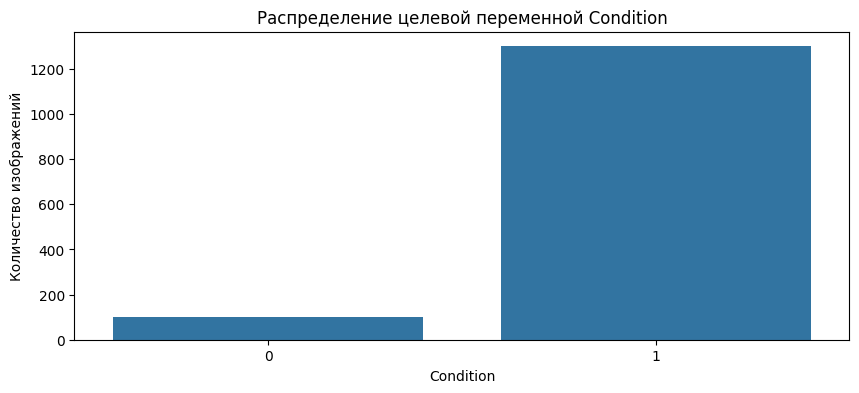

In [17]:
plt.figure(figsize=(10, 4))
sns.countplot(data=train_data, x='Condition')
plt.title('Распределение целевой переменной Condition')
plt.xlabel('Condition')
plt.ylabel('Количество изображений')
plt.show()

Да, видим, что переменная `Condition` принимает все же два значения: `0` и `1`, поэтому задачу на изображениях можно формулировать как задачу бинарной классификации.

Распределение классов оказалось все же несбалансированным:

- `Condition = 1`: 1300 изображений, около 92.9% выборки
- `Condition = 0`: 99 изображений, около 7.1% выборки

Классы явно представлены в данных неравномерно. Если модель будет всегда предсказывать класс `1`, она уже получит accuracy около 92.9%, но такая модель не будет полезной, потому что она не научится различать оба состояния автомобиля.

Поэтому в дальнейшем accuracy нельзя нам будет использовать как единственную метрику качества. Для оценки моделей дополнительно будем использовать precision, recall, F1-score, ROC-AUC и confusion matrix. Особенно важно будет анализировать качество по классу `Condition = 0`

Также не забудем, при разбиении данных на train/validation/test нужно использовать стратификацию по `Condition`, чтобы доли классов в подвыборках оставались похожими на исходное распределение

### Визуальная проверка классов

Теперь проверим, что именно означают значения `Condition = 0` и `Condition = 1` на изображениях. Откроем несколько изображений из каждого класса и визуально проверим, отличаются ли они по наличию повреждений

Посмотрим на первое изображение датасета

In [ ]:
example_image = plt.imread(DATA_DIR / 'trainImages' / train_data.iloc[0, 0])

In [25]:
example_image.shape

(418, 630, 3)

In [26]:
example_image.dtype

dtype('uint8')

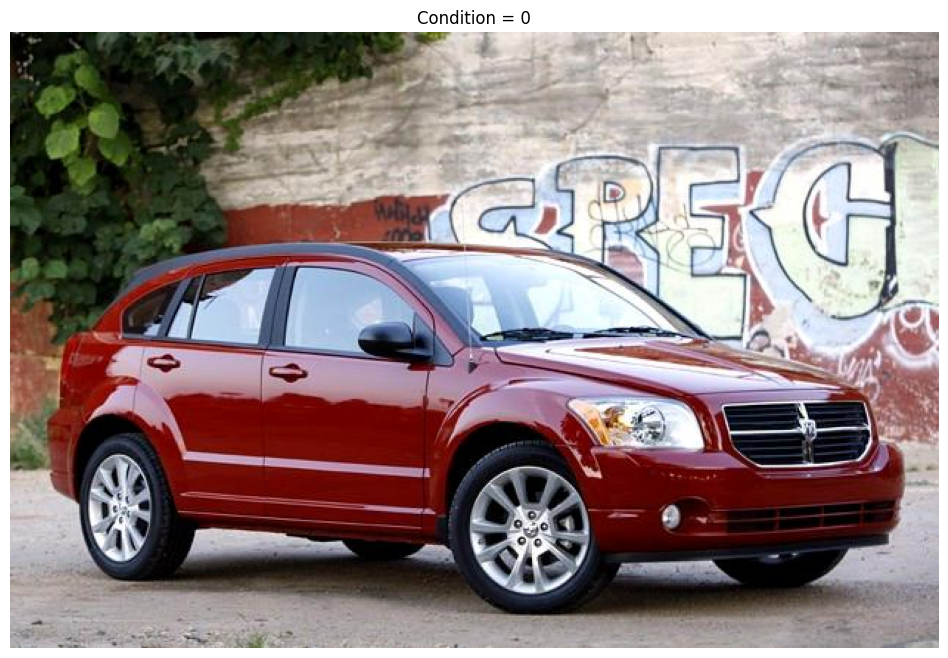

In [28]:
plt.figure(figsize=(12, 8))
plt.imshow(example_image)
plt.title(f'Condition = {train_data.iloc[0, -2]}')
plt.axis('off')
plt.show()

Да, видно, что нет каких-то повреждений

Напишем функцию для вывода примеров

In [37]:
def show_images_by_condition(data, condition_value, n_images=6, random_state=42):
    sample_cond = data[data['Condition'] == condition_value].sample(n_images, random_state=random_state)
    image_paths = sample_cond['Image_path'].tolist()
    plt.figure(figsize=(12, 8))
    for i in range(len(image_paths)):
        image = plt.imread(DATA_DIR / 'trainImages' / image_paths[i])
        plt.subplot(2, 3, i+1)
        plt.imshow(image)
        plt.title(f'{image_paths[i]}.Condition = {condition_value}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

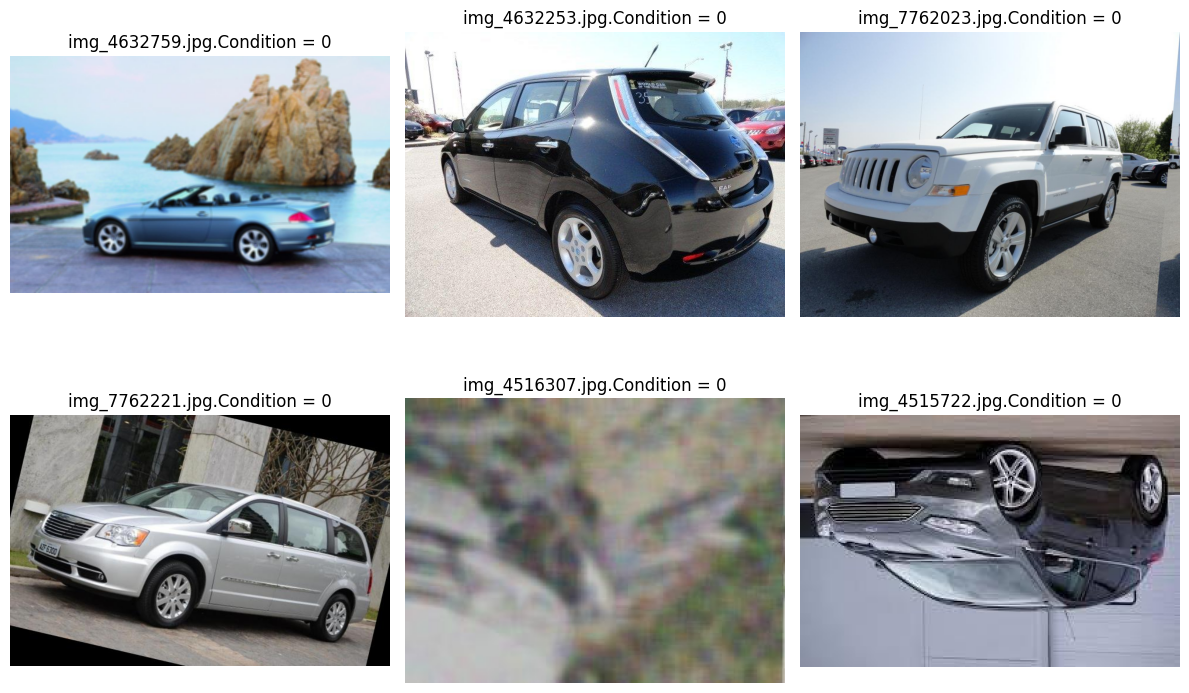

In [38]:
show_images_by_condition(train_data, condition_value=0, n_images=6)

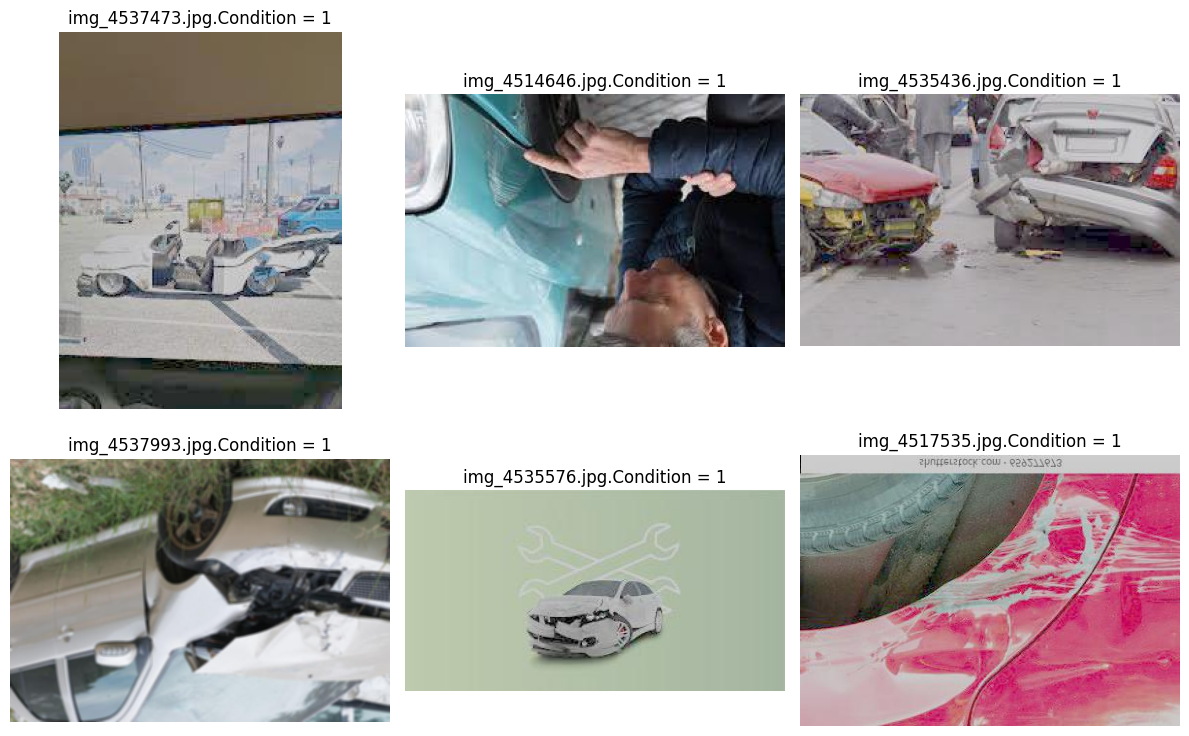

In [39]:
show_images_by_condition(train_data, condition_value=1, n_images=6)

Видно, что переменная `Condition` связана с наличием повреждений автомобиля.

Для класса `Condition = 0` в выборке в основном представлены автомобили без заметных повреждений. Для класса `Condition = 1` в большинстве примеров видны повреждения автомобиля, по типу деформация кузова, следы аварии, вмятины или другие визуальные признаки страхового случая.

Переменную `Condition` можно использовать как целевую переменную для наших задач.

При этом мы видим некоторые проблемы качества данных:
- часть изображений имеет нестандартную ориентацию
- некоторые изображения размыты или плохо различимы
- фотографии отличаются по масштабу, ракурсу, освещению и фону

Эти особенности важно учитывать при дальнейшем обучении модели

### Проверка изображений

Нам необходимо убедиться, что все изображения из столбца `Image_path` действительно существуют в папке `trainImages`. Это важно, потому что при обучении модели `Dataset` будет по каждой строке таблицы открывать соответствующее изображение. Если хотя бы часть файлов отсутствует или указана неверно, обучение прервется с ошибкой

In [41]:
image_data = train_data[['Image_path', 'Condition']].copy()
image_data.head()

,Image_path,Condition
0,img_4513976.jpg,0
1,img_7764995.jpg,1
2,img_451308.jpg,0
3,img_7768372.jpg,1
4,img_7765274.jpg,1


In [42]:
image_data['full_image_path'] = image_data['Image_path'].apply(lambda x: DATA_DIR / 'trainImages' / x)
image_data.head()

,Image_path,Condition,full_image_path
0,img_4513976.jpg,0,Fast_Furious_Insured\trainImages\img_4513976.jpg
1,img_7764995.jpg,1,Fast_Furious_Insured\trainImages\img_7764995.jpg
2,img_451308.jpg,0,Fast_Furious_Insured\trainImages\img_451308.jpg
3,img_7768372.jpg,1,Fast_Furious_Insured\trainImages\img_7768372.jpg
4,img_7765274.jpg,1,Fast_Furious_Insured\trainImages\img_7765274.jpg


In [43]:
image_data['file_exists'] = image_data['full_image_path'].apply(lambda x: x.exists())
image_data['file_exists'].value_counts()

file_exists
True    1399
Name: count, dtype: int64

Все изображения, указанные в столбце `Image_path`, найдены в папке `trainImages`. Значит, таблица с разметкой корректно связана с файлами изображений, и можно переходить к проверке размеров и форматов изображений

Перед обучением CNN необходимо проверить размеры изображений. В датасете изображения могут иметь разную ширину и высоту, но нейронная сеть обычно получает батчи тензоров одинакового размера Поэтому перед подачей в модель изображения будут приводиться к единому размеру. Однако сначала нужно посмотреть исходное распределение размеров, чтобы понимать, насколько изображения отличаются между собой

Посмотрим на второе изображение

In [44]:
image2 = plt.imread(image_data.loc[0, 'full_image_path'])

In [45]:
image2.shape

(418, 630, 3)

In [46]:
image2.dtype

dtype('uint8')

Как и ожидалось, у нас изображение цветное, получили формат `(height, width, 3)`, где:
- `height` - высота изображения
- `width` - ширина изображения
- `3` - количество цветовых каналов RGB

`dtype` нам показал тип данных пикселей `uint8`, где значения пикселей находятся в диапазоне от 0 до 255

Пройдемся по всем изображениям и сохраним их размеры в список

In [47]:
image_shapes = []
for path in image_data['full_image_path']:
    image = plt.imread(path)
    image_shapes.append(image.shape)

In [48]:
image_shapes[:5]

[(418, 630, 3), (183, 276, 3), (563, 750, 3), (682, 1024, 3), (381, 678, 3)]

In [50]:
image_size_data = pd.DataFrame(image_shapes, columns=['height', 'width', 'channels'])
image_size_data.head()

,height,width,channels
0,418,630,3
1,183,276,3
2,563,750,3
3,682,1024,3
4,381,678,3


In [51]:
image_size_data.describe()

,height,width,channels
count,1399.000000,1399.000000,1399.0
mean,396.537527,599.487491,3.0
std,381.151273,529.688154,0.0
min,69.000000,92.000000,3.0
25%,183.000000,275.000000,3.0
50%,200.000000,311.000000,3.0
75%,510.000000,800.000000,3.0
max,4032.000000,4500.000000,3.0


In [52]:
image_size_data['channels'].value_counts()

channels
3    1399
Name: count, dtype: int64

Все изображения имеют 3 канала, значит датасет полностью RGB

построим графики распределения ширины и высоты

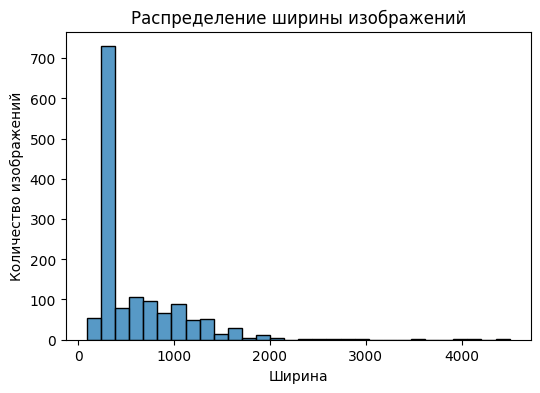

In [53]:
plt.figure(figsize=(6, 4))
sns.histplot(image_size_data['width'], bins=30)
plt.title('Распределение ширины изображений')
plt.xlabel('Ширина')
plt.ylabel('Количество изображений')
plt.show()

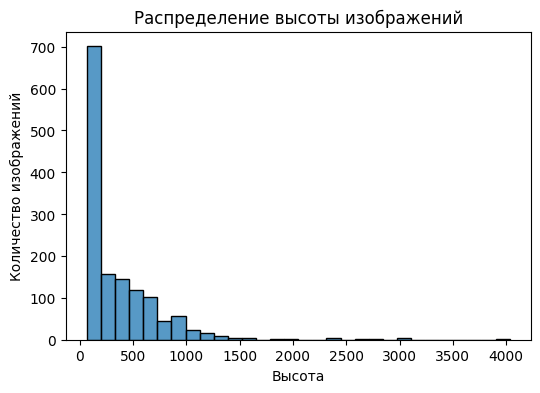

In [54]:
plt.figure(figsize=(6, 4))
sns.histplot(image_size_data['height'], bins=30)
plt.title('Распределение высоты изображений')
plt.xlabel('Высота')
plt.ylabel('Количество изображений')
plt.show()

Размеры файлов сильно различаются. Большая часть изображений имеет относительно небольшой размер, но также присутствуют изображения с очень большой шириной или высотой. Перед обучением CNN изображения нам необходимо привести к единому размеру

Также проверим, можно ли открыть каждое изображение из обучающей выборки

In [55]:
broken_images = []
for path in image_data['full_image_path']:
    try:
        try_image = plt.imread(path)
    except Exception as error:
        broken_images.append((path, error))

In [56]:
len(broken_images)

0

Все файлы из обучающей выборки корректно открываются. Битых нет